In [ ]:
#step1 :
#Test Dataset Loading
from datasets import load_dataset

dataset = load_dataset("google-research-datasets/go_emotions", "simplified")

print(dataset)

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})


In [ ]:
# Emotion Detection Using Machine Learning
## Multi-Label Classification on GoEmotions Dataset

In [ ]:
#Step2 : Dataset Loading & Exploratory Data Analysis (EDA)

In [ ]:

# 1. Inspect the dataset structure and contents.
dataset
dataset["train"][0]



{'text': "My favourite food is anything I didn't have to cook myself.",
 'labels': [27],
 'id': 'eebbqej'}

In [ ]:
#2. Check train / validation / test sizes
print("Train size:", len(dataset["train"]))
print("Validation size:", len(dataset["validation"]))
print("Test size:", len(dataset["test"]))

Train size: 43410
Validation size: 5426
Test size: 5427


In [ ]:
#3 Understand the Emotions
label_names = dataset["train"].features["labels"].feature.names
print(label_names)


['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [ ]:
#4 Convert to Pandas
import pandas as pd

train_df = dataset["train"].to_pandas()
train_df.head()

,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


In [ ]:
#5  Count Emotion Distribution

from collections import Counter

all_labels = []

for labels in train_df["labels"]:
    all_labels.extend(labels)

label_counts = Counter(all_labels)

label_counts

Counter({np.int64(27): 14219,
         np.int64(0): 4130,
         np.int64(4): 2939,
         np.int64(15): 2662,
         np.int64(3): 2470,
         np.int64(1): 2328,
         np.int64(7): 2191,
         np.int64(18): 2086,
         np.int64(10): 2022,
         np.int64(20): 1581,
         np.int64(2): 1567,
         np.int64(17): 1452,
         np.int64(6): 1368,
         np.int64(25): 1326,
         np.int64(9): 1269,
         np.int64(22): 1110,
         np.int64(5): 1087,
         np.int64(26): 1060,
         np.int64(13): 853,
         np.int64(11): 793,
         np.int64(8): 641,
         np.int64(14): 596,
         np.int64(24): 545,
         np.int64(12): 303,
         np.int64(19): 164,
         np.int64(23): 153,
         np.int64(21): 111,
         np.int64(16): 77})

In [ ]:
#convert to readable format

emotion_counts = {
    label_names[k]: v for k, v in label_counts.items()
}

emotion_counts

{'neutral': 14219,
 'anger': 1567,
 'fear': 596,
 'annoyance': 2470,
 'surprise': 1060,
 'gratitude': 2662,
 'desire': 641,
 'optimism': 1581,
 'admiration': 4130,
 'confusion': 1368,
 'amusement': 2328,
 'approval': 2939,
 'caring': 1087,
 'embarrassment': 303,
 'realization': 1110,
 'disappointment': 1269,
 'grief': 77,
 'sadness': 1326,
 'curiosity': 2191,
 'joy': 1452,
 'love': 2086,
 'excitement': 853,
 'disapproval': 2022,
 'remorse': 545,
 'disgust': 793,
 'relief': 153,
 'pride': 111,
 'nervousness': 164}

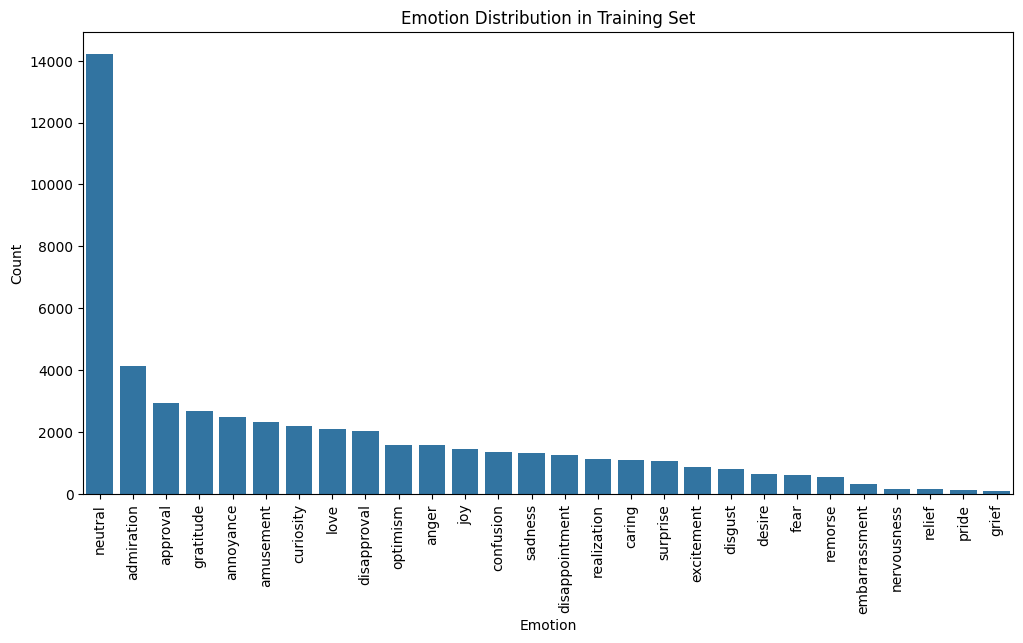

In [ ]:
# 6 Visualize Emotion Distribution

import matplotlib.pyplot as plt
import seaborn as sns

emotion_df = pd.DataFrame(
    emotion_counts.items(),
    columns=["Emotion", "Count"]
)

emotion_df = emotion_df.sort_values(by="Count", ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x="Emotion", y="Count", data=emotion_df)
plt.xticks(rotation=90)
plt.title("Emotion Distribution in Training Set")
plt.show()

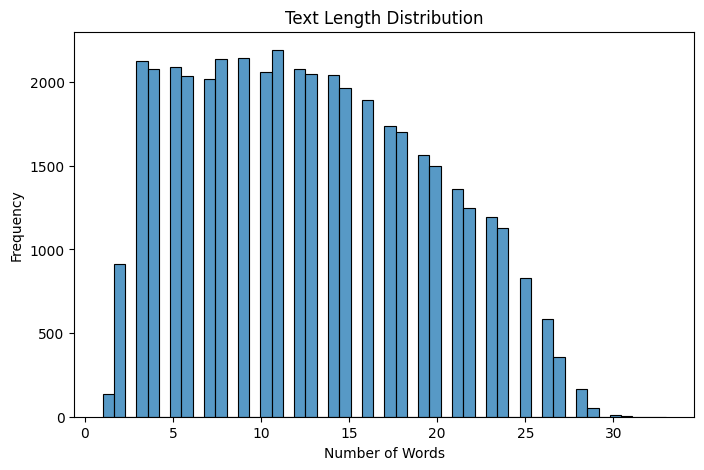

In [ ]:
# 7 Analyze Text Length Distribution

train_df["text_length"] = train_df["text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(train_df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print("Average text length:", train_df["text_length"].mean())

Average text length: 12.840175074867542


In [ ]:
# EDA Observations  :
# the dataset conatins 28 emotion labels with "neutral"
#the dataset is multi-label "one sentence can have multiple emotions ."
#the class distribution is imbalanced
#most texts are short (average length around 20 words)


In [ ]:
# Step3 : Data Preprocessing

In [ ]:
#1 Lowercase and Remove Noise

import re

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r"http\S+", "", text)
    # Remove non-alphabetic characters (punctuation, numbers)
    text = re.sub(r"[^a-z\s]", "", text)
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Apply to training, validation, and test sets
train_texts = [clean_text(x) for x in dataset["train"]["text"]]
val_texts = [clean_text(x) for x in dataset["validation"]["text"]]
test_texts = [clean_text(x) for x in dataset["test"]["text"]]

In [ ]:
#2 Prepare Multi-Label Targets

import numpy as np

# Number of emotions
num_labels = len(dataset["train"].features["labels"].feature.names)

# Convert labels to multi-hot encoding
def multi_hot(labels_list):
    y = np.zeros(num_labels)
    for label in labels_list:
        y[label] = 1
    return y

# Apply to train, validation, test
y_train = np.array([multi_hot(x) for x in dataset["train"]["labels"]])
y_val = np.array([multi_hot(x) for x in dataset["validation"]["labels"]])
y_test = np.array([multi_hot(x) for x in dataset["test"]["labels"]])

In [ ]:
#3 Remove Stopwords

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return " ".join([w for w in text.split() if w not in stop_words])

train_texts = [remove_stopwords(x) for x in train_texts]
val_texts = [remove_stopwords(x) for x in val_texts]
test_texts = [remove_stopwords(x) for x in test_texts]


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#4 Tokenization for ML Models (TF-IDF)

from sklearn.feature_extraction.text import TfidfVectorizer

# Limit max features to 10,000 to reduce dimensionality
vectorizer = TfidfVectorizer(max_features=10000)

# Fit on training data and transform all sets
X_train = vectorizer.fit_transform(train_texts)
X_val = vectorizer.transform(val_texts)
X_test = vectorizer.transform(test_texts)

In [ ]:
#5 Tokenization for BERT


from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Tokenize texts
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

In [ ]:
#6 Dataset Summary

print("Train X:", X_train.shape, "Y:", y_train.shape)
print("Validation X:", X_val.shape, "Y:", y_val.shape)
print("Test X:", X_test.shape, "Y:", y_test.shape)

Train X: (43410, 10000) Y: (43410, 28)
Validation X: (5426, 10000) Y: (5426, 28)
Test X: (5427, 10000) Y: (5427, 28)


In [ ]:
#Step4 : Model Building


In [ ]:
#Classical ML Models (TF-IDF)

In [ ]:
#1 Import Libraries

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier



In [ ]:
#2 Define Models
models = {
    "Logistic Regression": OneVsRestClassifier(LogisticRegression(max_iter=1000)),
    "Naive Bayes": OneVsRestClassifier(MultinomialNB()),
    "SVM": OneVsRestClassifier(LinearSVC()),
    "Random Forest": OneVsRestClassifier(RandomForestClassifier(n_estimators=100)),
    "KNN": OneVsRestClassifier(KNeighborsClassifier(n_neighbors=5))
}


In [ ]:
#3  Train All Models

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model

Training Logistic Regression...
Training Naive Bayes...
Training SVM...
Training Random Forest...
Training KNN...


In [ ]:
# BERT Deep Learning Model

In [ ]:
#1  Convert Encodings to Dataset

import torch

class GoEmotionsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

train_dataset = GoEmotionsDataset(train_encodings, y_train)
val_dataset = GoEmotionsDataset(val_encodings, y_val)
test_dataset = GoEmotionsDataset(test_encodings, y_test)

In [ ]:
#2 Load Pretrained BERT Model

from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_labels,
    problem_type="multi_label_classification"
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 543.92it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those pa

In [ ]:
#3 Define Trainer


from transformers import TrainingArguments, Trainer
from sklearn.metrics import f1_score, accuracy_score


training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",       # Transformers 5.2
    save_strategy="epoch",
    logging_dir='./logs',
    logging_steps=50,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to="none"             # évite les logs non désirés
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.sigmoid(torch.tensor(logits))
    y_pred = (probs >= 0.5).int()
    return {
        "f1_micro": f1_score(labels, y_pred, average="micro"),
        "f1_macro": f1_score(labels, y_pred, average="macro"),
        "accuracy": accuracy_score(labels, y_pred)
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
#4 Train BERT

trainer.train()

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,0.105962,0.102740,0.462179,0.175081,0.331183
2,0.097166,0.097271,0.510780,0.275074,0.383524


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.58it/s]
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.25it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.enco

TrainOutput(global_step=5428, training_loss=0.11524971048007929, metrics={'train_runtime': 40165.3589, 'train_samples_per_second': 2.162, 'train_steps_per_second': 0.135, 'total_flos': 3391594175710080.0, 'train_loss': 0.11524971048007929, 'epoch': 2.0})

In [ ]:
# Step 5 : Evaluation & Comparison

In [ ]:
#1. Evaluation of Classical ML Models

from sklearn.metrics import f1_score

results = {}

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    f1_micro = f1_score(y_test, y_pred, average='micro')
    f1_macro = f1_score(y_test, y_pred, average='macro')

    results[name] = {
        "F1 Micro": f1_micro,
        "F1 Macro": f1_macro
    }

results

{'Logistic Regression': {'F1 Micro': 0.42299156679982247,
  'F1 Macro': 0.2485970145740353},
 'Naive Bayes': {'F1 Micro': 0.09495723975228545,
  'F1 Macro': 0.027077881518399256},
 'SVM': {'F1 Micro': 0.4696908055329536, 'F1 Macro': 0.3364552717249637},
 'Random Forest': {'F1 Micro': 0.46732794764290825,
  'F1 Macro': 0.2943851413274567},
 'KNN': {'F1 Micro': 0.3186330660557465, 'F1 Macro': 0.12452082479552293}}

In [ ]:
#2. Evaluate BERT
bert_results = trainer.evaluate(test_dataset)

results["BERT"] = {
    "F1 Micro": bert_results["eval_f1_micro"],
    "F1 Macro": bert_results["eval_f1_macro"]
}

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
#3. Create Comparison Table
import pandas as pd
results_df = pd.DataFrame(results).T
results_df

,F1 Micro,F1 Macro
Logistic Regression,0.422992,0.248597
Naive Bayes,0.094957,0.027078
SVM,0.469691,0.336455
Random Forest,0.467328,0.294385
KNN,0.318633,0.124521
BERT,0.505270,0.270520


<Axes: >

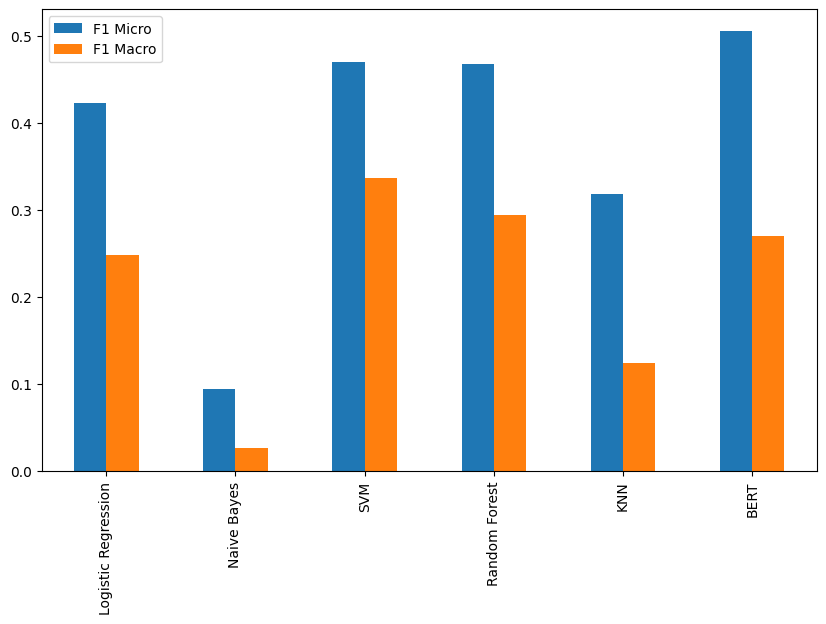

In [ ]:
#4. Graph Comparison
results_df.plot(kind="bar", figsize=(10,6))